In [1]:
import pandas as pd

In [2]:
meta = pd.read_csv('/mnt/data/project0062/cosmx_gray/data/old_comb/tables/comb-meta.tsv', sep='\t')

In [3]:
coords = meta[['sample_name','CenterX_global_px', 'CenterY_global_px']]
coords


,sample_name,CenterX_global_px,CenterY_global_px
0,CTRL01,85969.0,163444.0
1,CTRL01,86122.0,163426.0
2,CTRL01,86218.0,163445.0
3,CTRL01,86041.0,163448.0
4,CTRL01,85996.0,163380.0
...,...,...,...
1326781,PWCF06,44075.0,-4100.0
1326782,PWCF06,43651.0,-4114.0
1326783,PWCF06,43850.0,-4103.0
1326784,PWCF06,40495.0,-4103.0


In [7]:
import numpy as np
import pandas as pd

# coords is a 2-col DF: CenterX_global_px, CenterY_global_px
# meta contains sample_name

sample_key = "slide_name"

# 1) base coords
x0 = coords["CenterX_global_px"].to_numpy(dtype=np.float32)
y0 = coords["CenterY_global_px"].to_numpy(dtype=np.float32)

# 2) samples as plain strings
samples = meta[sample_key].astype(str)

# 3) set a safe gap (global x span * 2)
x_range = float(x0.max() - x0.min())
gap = x_range * 2.0  # increase if you want more spacing

# 4) stable mapping sample -> index
sample_order = pd.unique(samples)  # keeps first-seen order
sample_to_idx = {s: i for i, s in enumerate(sample_order)}

idx = samples.map(sample_to_idx).to_numpy(dtype=np.float32)

# Safety check (should never trigger)
if np.isnan(idx).any():
    bad = samples[pd.isna(samples.map(sample_to_idx))].unique()
    raise ValueError(f"Unmapped sample(s) detected: {bad}")

# 5) repelled coords
meta["coords_x"] = x0 + idx * gap
meta["coords_y"] = y0


In [8]:
meta

,cell_id,fov,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,Max.CD68,...,age,mutation,sex,bmi,_scvi_batch,_scvi_labels,leiden_scVI,ct_scVI,coords_x,coords_y
0,c_3_1_3,1,11913,0.92,124,135,338.0,2788,644.8,6000,...,UNK,UNK,UNK,UNK,2,0,24,unknown,85969.0,163444.0
1,c_3_1_4,1,10226,0.98,126,123,368.3,2100,610.4,7832,...,UNK,UNK,UNK,UNK,2,0,20,neutrophils,86122.0,163426.0
2,c_3_1_5,1,5684,0.53,63,120,301.7,728,820.7,3008,...,UNK,UNK,UNK,UNK,2,0,24,unknown,86218.0,163445.0
3,c_3_1_6,1,4008,0.54,53,99,366.9,828,1058.0,7220,...,UNK,UNK,UNK,UNK,2,0,13,unknown,86041.0,163448.0
4,c_3_1_7,1,2753,0.65,79,51,1204.7,4076,784.5,6660,...,UNK,UNK,UNK,UNK,2,0,13,unknown,85996.0,163380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326781,c_4_192_1024,192,11110,0.77,140,108,515.6,4264,467.1,6224,...,UNK,UNK,UNK,UNK,2,0,5,fibroblasts,808049.0,-4100.0
1326782,c_4_192_1025,192,4487,0.56,124,69,13928.8,55152,416.3,4584,...,UNK,UNK,UNK,UNK,2,0,6,AT2,807625.0,-4114.0
1326783,c_4_192_1026,192,1598,0.51,38,74,483.2,2584,572.6,3796,...,UNK,UNK,UNK,UNK,2,0,11,plasma,807824.0,-4103.0
1326784,c_4_192_1027,192,8277,0.84,112,94,1276.8,3164,479.0,3016,...,UNK,UNK,UNK,UNK,2,0,13,unknown,804469.0,-4103.0


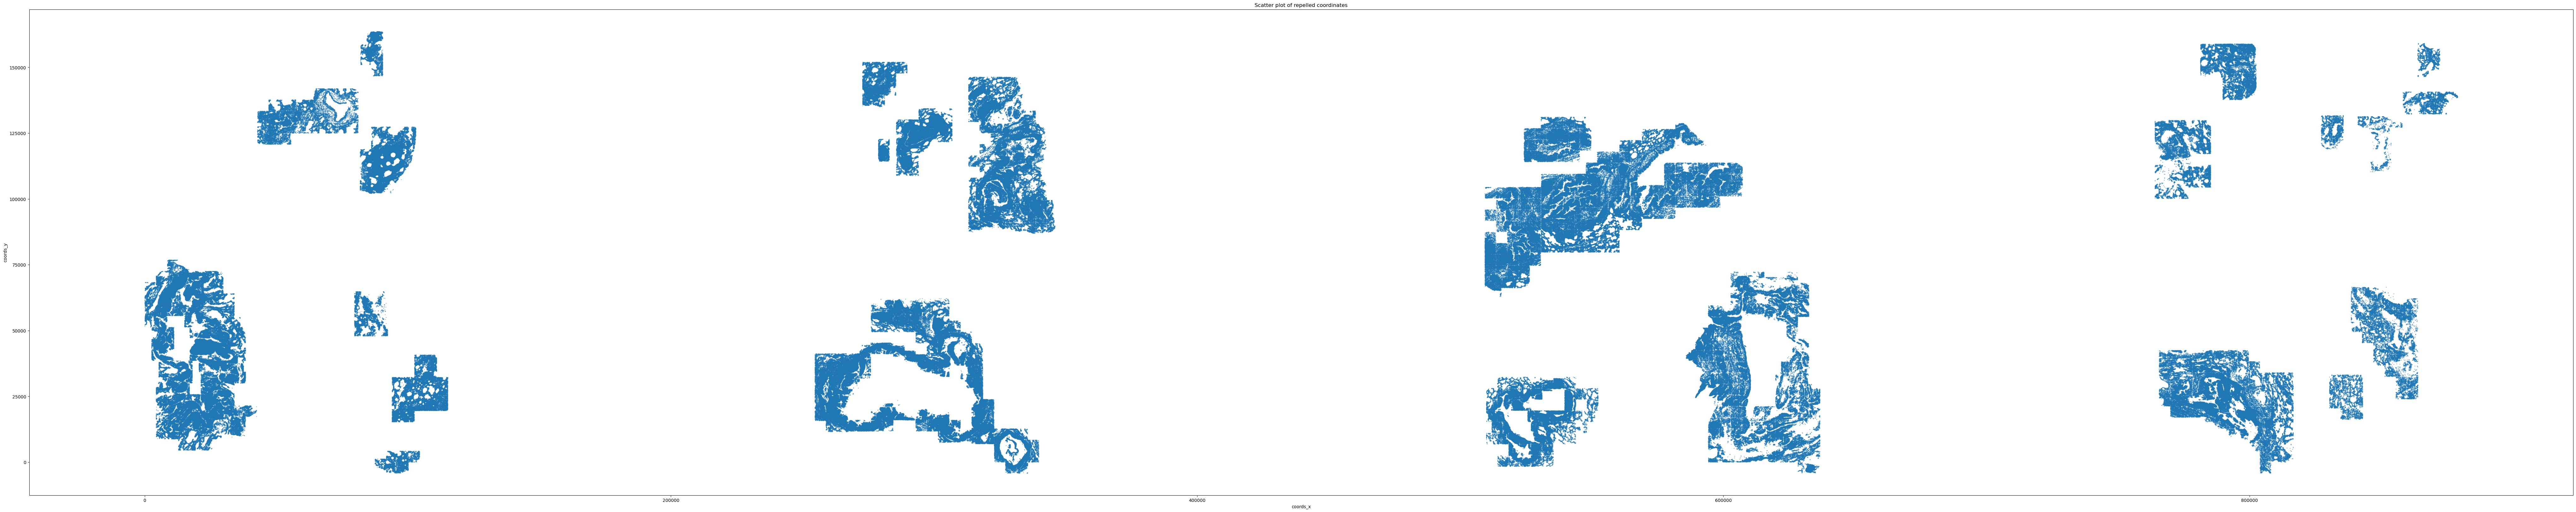

In [9]:
import matplotlib.pyplot as plt

x = meta["coords_x"].to_numpy()
y = meta["coords_y"].to_numpy()

plt.figure(figsize=(200, 20))
plt.scatter(x, y, s=1, alpha=0.4)
plt.xlabel("coords_x")
plt.ylabel("coords_y")
plt.title("Scatter plot of repelled coordinates")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()


In [12]:
new_coords = meta[['coords_x', 'coords_y']]
new_coords

,coords_x,coords_y
0,85969.0,163444.0
1,86122.0,163426.0
2,86218.0,163445.0
3,86041.0,163448.0
4,85996.0,163380.0
...,...,...
1326781,2845313.0,-4100.0
1326782,2844889.0,-4114.0
1326783,2845088.0,-4103.0
1326784,2841733.0,-4103.0


In [15]:
min(new_coords['coords_x'])
max(new_coords['coords_x'])
min(new_coords['coords_y'])
max(new_coords['coords_y'])

163652.0